# Week 3: Evaluation using reference ground-truth, mitigation, and calibration

You now receive:

- `week3_validation_reference.csv`
- `week3_test_observed.csv`
- `week3_test_reference.csv`

These files let you compare evaluation against the labels available to the modelling pipeline, $Y^{obs}$, and the best available reference labels, $Y^{ref}$.

You now receive the "clean" reference labels (`income_reference`) for the validation and test sets. 

Your objective this week is to uncover the **root cause** of the biases and anomalies you hypothesized in Week 2. By comparing your model's performance against the observed labels ($Y^{obs}$) versus the clean reference labels ($Y^{ref}$), you will finally validate (or invalidate!) your previous hypotheses.

Once you have identified the true source of the bias, you will design and implement a mitigation strategy of your choice to correct it. 

**Rules**
- Do not train a predictive model on `income_reference`.                                    
- Reference validation may be used for final model selection or calibration only if you explicitly state and defend that design choice.                         
- Reference test is used exactly *once* for your final evaluation.                                         
- Preserve `row_id` when joining files and verify one-to-one joins.

In [ ]:
%pip -q install fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "week2_train_observed.csv")
val_obs = pd.read_csv(DATA_DIR / "week2_validation_observed.csv")
val_ref = pd.read_csv(DATA_DIR / "week3_validation_reference.csv")
test_obs = pd.read_csv(DATA_DIR / "week3_test_observed.csv")
test_ref = pd.read_csv(DATA_DIR / "week3_test_reference.csv")

# TODO: assert unique row_id values and exact alignment of feature columns.
assert train['row_id'].is_unique, "Train row_id values are not unique"
assert val_obs['row_id'].is_unique, "Validation observed row_id values are not unique"
assert val_ref['row_id'].is_unique, "Validation reference row_id values are not unique"
print(train.shape, val_obs.shape, val_ref.shape, test_obs.shape, test_ref.shape)

(18000, 15) (6000, 15) (6000, 16) (6000, 15) (6000, 16)


To start with - Compare $Y^{obs}$ and $Y^{ref}$ on validation and test data. Report overall disagreement, disagreement conditional on each label, group-specific disagreement, and intersections. Inspect which feature regions contain disagreements without assuming the reference label is infallible.

In [20]:
(test_ref['income_observed'] != test_obs['income_observed']).sum(), (val_ref['income_observed'] != val_obs['income_observed']).sum()

(np.int64(0), np.int64(0))

Dataset: validation_reference
  Total rows: 6000
  Total disagreements: 242.0 (4.03%)
  Disagreements by label:
    n_disagree_income_1: 30.0
    pct_disagree_income_1: 0.014955134596211365
    n_disagree_income_0: 212.0
    pct_disagree_income_0: 0.053079619429143715

Dataset: test_reference
  Total rows: 6000
  Total disagreements: 249.0 (4.15%)
  Disagreements by label:
    n_disagree_income_0: 223.0
    pct_disagree_income_0: 0.05563872255489022
    n_disagree_income_1: 26.0
    pct_disagree_income_1: 0.013052208835341365

Disagreement matrix for validation_reference:


,AIAN specified/other,American Indian,Asian,Black,Other race,Pacific Islander,Two or more races,White
Female,0.0,1.0,27.0,12.0,3.0,0.0,2.0,159.0
Male,0.0,0.0,3.0,0.0,0.0,0.0,4.0,31.0


Disagreement matrix for test_reference:


,AIAN specified/other,American Indian,Asian,Black,Other race,Pacific Islander,Two or more races,White
Female,0.0,1.0,10.0,26.0,4.0,0.0,4.0,147.0
Male,0.0,0.0,2.0,3.0,5.0,0.0,0.0,47.0


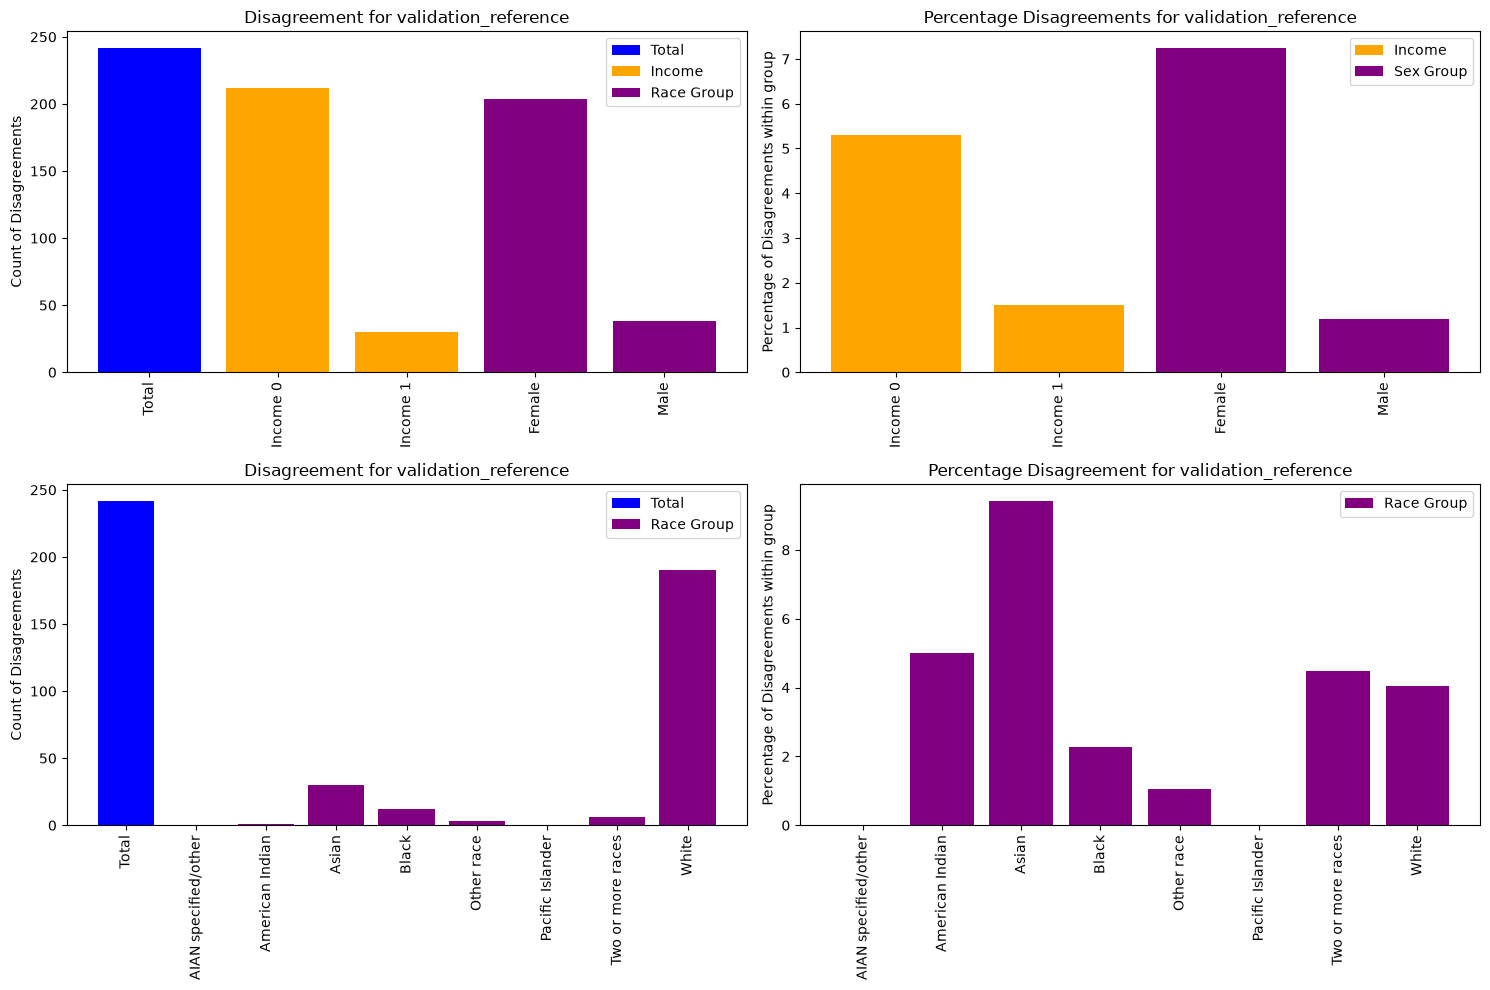

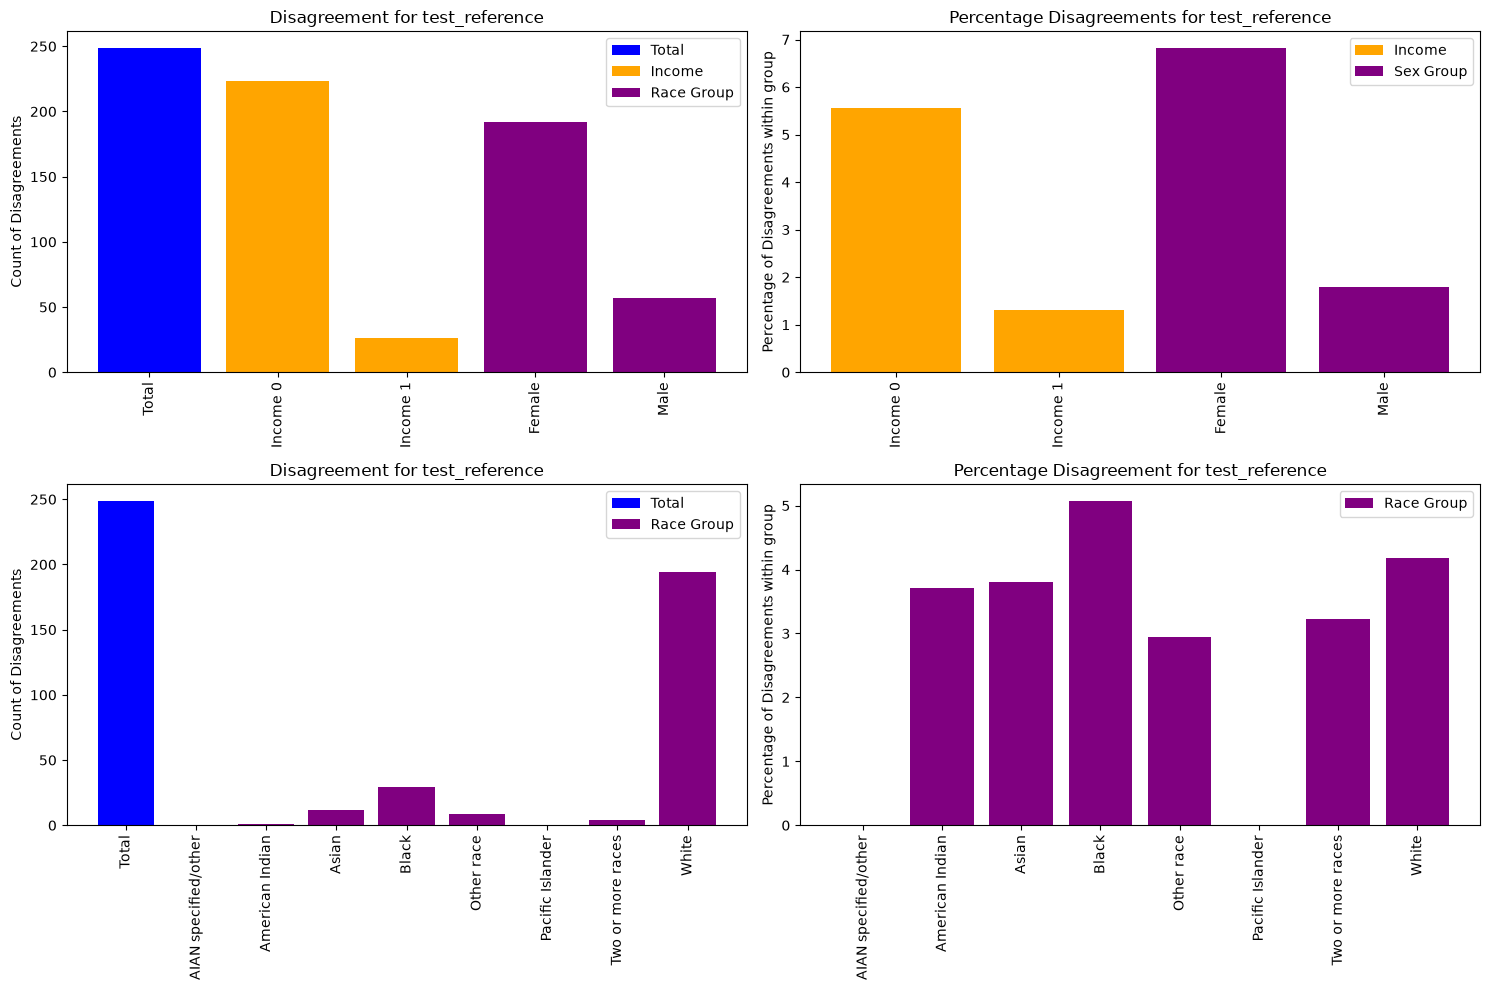

In [88]:
# TODO: join observed and reference files by row_id.
DATAFRAMES = {"train":train, "validation_observed": val_obs, "validation_reference": val_ref, "test_observed": test_obs, "test_reference": test_ref}
SENSITIVE_ATTRIBUTES = ["SEX_group", "RACE_group"]
# TODO: quantify and visualize label disagreement.
# Overall Disagreement
def summarize_disagreement(ref_dfs, observed_col="income_observed", reference_col="income_reference"):
    summary = {}
    for name, df in ref_dfs.items():
        summary_item = {}
        assert reference_col in df.columns, f"{name} does not have a {reference_col} column"
        assert observed_col in df.columns, f"{name} does not have a {observed_col} column"
        summary_item["n_rows"] = len(df)
        
        # Disagreement counts and percentages
        n_disagree = (df[observed_col] != df[reference_col]).sum()
        summary_item["n_disagree"] = float(n_disagree)
        summary_item["pct_disagree"] = float(n_disagree / len(df))
        
        # Disagreement by label value
        label_disagreement = {}
        for label in df[observed_col].unique():
            n_disagree_label = ((df[observed_col] == label) & (df[observed_col] != df[reference_col])).sum()
            label_disagreement[f"n_disagree_income_{label}"] = float(n_disagree_label)
            label_disagreement[f"pct_disagree_income_{label}"] = float(n_disagree_label / (df[observed_col] == label).sum())
        summary_item["label_disagreement"] = label_disagreement
        
        # Disagreement by sensitive attribute value
        sens_dict = {}
        for attr in SENSITIVE_ATTRIBUTES:
            for value in df[attr].unique():
                n_disagree_attr = ((df[attr] == value) & (df[observed_col] != df[reference_col])).sum()
                sens_dict[f"n_disagree_{attr}_{value}"] = float(n_disagree_attr)
                sens_dict[f"pct_disagree_{attr}_{value}"] = float(n_disagree_attr / (df[attr] == value).sum())
        summary_item["sensitive_disagreement"] = sens_dict
        
        # Disagreement by intersection of sensitive attribute values
        intersection_dict = {}
        for attr1 in SENSITIVE_ATTRIBUTES:
            for value1 in df[attr1].unique():
                for attr2 in SENSITIVE_ATTRIBUTES:
                    if attr1 == attr2:
                        continue
                    for value2 in df[attr2].unique():
                        n_disagree_intersection = ((df[attr1] == value1) & (df[attr2] == value2) & (df[observed_col] != df[reference_col])).sum()
                        intersection_dict[f"n_disagree_{attr1}_{value1}_{attr2}_{value2}"] = float(n_disagree_intersection)
                        intersection_dict[f"pct_disagree_{attr1}_{value1}_{attr2}_{value2}"] = float(n_disagree_intersection / ((df[attr1] == value1) & (df[attr2] == value2)).sum())
        summary_item["intersection_disagreement"] = intersection_dict
        
        summary[name] = summary_item
    return summary

def sex_race_disagreement_matrix(name, summary_item):
    matrix = pd.DataFrame(index=sorted(DATAFRAMES[name]['SEX_group'].unique()), columns=sorted(DATAFRAMES[name]['RACE_group'].unique()))
    
    for sex in matrix.index:
        for race in matrix.columns:
            n_disagree = summary_item['intersection_disagreement'].get(f"n_disagree_SEX_group_{sex}_RACE_group_{race}", 0)
            matrix.loc[sex, race] = n_disagree
    return matrix


def print_disagreement_summary(summary, label_grouping=True, sensitive_grouping=True, intersection_grouping=True):
    for name, summary_item in summary.items():
        print(f"Dataset: {name}")
        print(f"  Total rows: {summary_item['n_rows']}")
        print(f"  Total disagreements: {summary_item['n_disagree']} ({summary_item['pct_disagree']*100:.2f}%)")
        
        if label_grouping:
            print("  Disagreements by label:")
            for label, value in summary_item["label_disagreement"].items():
                print(f"    {label}: {value}")
                
        if sensitive_grouping:
            print("  Disagreements by sensitive attribute:")
            for attr, value in summary_item["sensitive_disagreement"].items():
                print(f"    {attr}: {value}")
                
        if intersection_grouping:
            print("  Disagreements by intersection of sensitive attributes:")
            for intersection, value in summary_item["intersection_disagreement"].items():
                print(f"    {intersection}: {value}")
        print()
        
def plot_disagreement_summary(summary):
    for name, summary_item in summary.items():
        n_rows = 2
        fig, axes = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
        axes = axes.flatten()
        
        
        axes[0].bar(["Total"], [summary_item['n_disagree']], color='blue', label="Total")
        # Disagreements by label
        axes[0].bar(["Income 0", "Income 1"], [summary_item['label_disagreement']['n_disagree_income_0'], summary_item['label_disagreement']['n_disagree_income_1']], color='orange', label="Income")
        # Disagreements by sex groups
        sex_groups = sorted(DATAFRAMES[name]['SEX_group'].unique())
        axes[0].bar(sex_groups, [summary_item['sensitive_disagreement'][f'n_disagree_SEX_group_{race}'] for race in sex_groups], color='purple', label="Race Group")
        axes[0].set_ylabel("Count of Disagreements")
        axes[0].set_title(f"Disagreement for {name}")
        axes[0].legend() 
        axes[0].tick_params(axis='x', rotation=90)       
        
        # Percentage of disagreements by label
        axes[1].bar(["Income 0", "Income 1"], [summary_item['label_disagreement']['pct_disagree_income_0']*100, summary_item['label_disagreement']['pct_disagree_income_1']*100], color='orange', label="Income")
        # Percentage of disagreements by sex groups
        axes[1].bar(sex_groups, [summary_item['sensitive_disagreement'][f'pct_disagree_SEX_group_{race}']*100 for race in sex_groups], color='purple', label="Sex Group")
        axes[1].set_ylabel("Percentage of Disagreements within group")
        axes[1].set_title(f"Percentage Disagreements for {name}")
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=90)
                
        # Disagreements by Race groups
        race_groups = sorted(DATAFRAMES[name]['RACE_group'].unique())
        axes[2].bar(["Total"], [summary_item['n_disagree']], color='blue', label="Total")
        axes[2].bar(race_groups, [summary_item['sensitive_disagreement'][f'n_disagree_RACE_group_{race}'] for race in race_groups], color='purple', label="Race Group")
        axes[2].set_ylabel("Count of Disagreements")
        axes[2].set_title(f"Disagreement for {name}")
        axes[2].legend()
        axes[2].tick_params(axis='x', rotation=90)
        
        # Percentage of disagreements by Race groups
        axes[3].bar(race_groups, [summary_item['sensitive_disagreement'][f'pct_disagree_RACE_group_{race}']*100 for race in race_groups], color='purple', label="Race Group")
        axes[3].set_ylabel("Percentage of Disagreements within group")
        axes[3].set_title(f"Percentage Disagreement for {name}")
        axes[3].legend()
        axes[3].tick_params(axis='x', rotation=90)
        
        plt.tight_layout()
        plt.show()

summary = summarize_disagreement({key: value for key, value in DATAFRAMES.items() if "reference" in key})
print_disagreement_summary(summary, label_grouping=True, sensitive_grouping=False, intersection_grouping=False)
for name, summary_item in summary.items():
    print(f"Disagreement matrix for {name}:")
    matrix = sex_race_disagreement_matrix(name, summary_item)
    display(matrix)
plot_disagreement_summary(summary)


# TODO: test the Week 2 hypotheses without reading the new metadata.


Re-evaluate the original model twice

For the same scores and decisions, produce two complete audits:

1. against `income_observed`;
2. against `income_reference`.

Any difference is caused by the evaluation target, not by a changed model. Discuss which conclusions reverse or materially change.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, precision_score, recall_score
from fairlearn.metrics import MetricFrame, selection_rate, count, equalized_odds_difference, equalized_odds_ratio, demographic_parity_difference, demographic_parity_ratio

# TODO: reconstruct your Week 2 baseline.
LABEL = "income_observed"
ID = "row_id"
SENSITIVE1 = "SEX_group"
SENSITIVE2 = "RACE_group"

# TODO: choose features and justify exclusions.
#FEATURE_COLUMNS = ["AGEP", "COW", "SCHL", "MAR", "OCCP", "POBP", "RELP", "WKHP"]
NUMERIC_FEATURES = ["AGEP", "SCHL", "WKHP"]
CATEGORICAL_FEATURES = ["COW", "MAR", "OCCP", "POBP", "RELP"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# TODO: write a model factory that handles numeric and categorical columns.
def make_model(frame):
    numeric = [c for c in NUMERIC_FEATURES if c in frame.columns]
    categorical = [c for c in CATEGORICAL_FEATURES if c in frame.columns]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])
    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000)),
    ])

# TODO: fit a baseline on observed training labels and evaluate against observed validation labels.
lr_model = make_model(train)
lr_model.fit(train[FEATURE_COLUMNS], train[LABEL])

lr_train_pred = lr_model.predict(DATAFRAMES['train'][FEATURE_COLUMNS])
lr_train_proba = lr_model.predict_proba(DATAFRAMES['train'][FEATURE_COLUMNS])[:,1]

lr_val_pred = lr_model.predict(DATAFRAMES['validation_observed'][FEATURE_COLUMNS])
lr_val_proba = lr_model.predict_proba(DATAFRAMES['validation_observed'][FEATURE_COLUMNS])[:,1]

lr_test_pred = lr_model.predict(DATAFRAMES['test_observed'][FEATURE_COLUMNS])
lr_test_proba = lr_model.predict_proba(DATAFRAMES['test_observed'][FEATURE_COLUMNS])[:,1]

def baseline_model(X):
    # Simple baseline model: predict income based on education level (SCHL)
    return (X['SCHL'] >= 21).astype(int)  # 21 corresponds to Bachelor's Degree

baseline_train_pred = baseline_model(DATAFRAMES['train'])
baseline_val_pred = baseline_model(DATAFRAMES['validation_observed'])
baseline_test_pred = baseline_model(DATAFRAMES['test_observed'])

# TODO: create a reusable audit function accepting y_eval, scores, predictions, and sensitive features.
def true_positive_rate(y_true, y_pred):
    return recall_score(y_true, y_pred, pos_label=1, zero_division=0)

def false_positive_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fp
    return fp / denominator if denominator > 0 else np.nan

def positive_predictive_value(y_true, y_pred):
    return precision_score(y_true, y_pred, pos_label=1, zero_division=0)

def negative_predictive_value(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    denominator = tn + fn
    return tn / denominator  if denominator else np.nan

LABEL_METRICS = {
    "count": count,
    "selection_rate": selection_rate,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "tpr": true_positive_rate,
    "fpr": false_positive_rate,
    "ppv": positive_predictive_value,
    "npv": negative_predictive_value,
}

def audit_model(y_eval, scores, predictions, sensitive_features):
    """
        y_eval: true labels
        scores: predicted probabilities
        predictions: predicted labels
        sensitive_features: DataFrame containing sensitive attributes
    """
    # Calculate accuracy and balanced accuracy
    mf = MetricFrame(
        metrics=LABEL_METRICS,
        y_true=y_eval,
        y_pred=predictions,
        sensitive_features=sensitive_features,
    )
    
    

# TODO: report utility, independence, separation, sufficiency, and calibration twice.
for name, df in DATAFRAMES.items():
    if "reference" in name:
        continue
    y_eval = df[LABEL]
    scores = lr_model.predict_proba(df[FEATURE_COLUMNS])[:, 1]
    predictions = lr_model.predict(df[FEATURE_COLUMNS])
    sensitive_features = df[[SENSITIVE1, SENSITIVE2]]
    
    print(f"Audit results for {name}:")
    audit_model(y_eval, scores, predictions, sensitive_features)

Audit results for train:
Audit results for validation_observed:
Audit results for test_observed:


HintL Design mitigation candidates

Compare at least four methods you could think of. You may add models. Every intervention requires a  rationale and a documented cost/tradeoff.

In [ ]:
# TODO: define the candidates and a common experiment protocol.
# Keep preprocessing, split, random seed, and evaluation consistent.

Hint: `ThresholdOptimizer` changes decisions, not probability calibration. `ExponentiatedGradient` trains a randomized classifier under a constraint. Equalized odds is evaluated relative to the label supplied during fitting.

In [ ]:
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression

# TODO: choose which validation label is appropriate for fitting a postprocessor.
# post = ThresholdOptimizer(estimator=base_model, constraints="equalized_odds", predict_method="predict_proba")
# post.fit(X_val, y_val_..., sensitive_features=A_val)

# TODO: implement, justify, and audit Fairlearn interventions.

Compare at least these score pipelines:

1. uncalibrated model;
2. calibration fitted to observed validation labels;
3. calibration fitted to reference validation labels.

Evaluate each against both observed and reference test labels. Keep calibration separate from decision postprocessing. Explain why a score can be calibrated against one label and miscalibrated against another.

In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Current sklearn pattern for a pre-fitted estimator. The calibration set
# must be disjoint from the model-fitting set:
# calibrated_obs = CalibratedClassifierCV(
#     estimator=FrozenEstimator(base_model), method="sigmoid"
# )
# calibrated_obs.fit(X_val, y_val_observed)

# TODO: implement all three pipelines, reliability plots, ECE, and log loss.

## 5. Final locked test evaluation

Select the final candidates before examining reference test results. Then produce evaluate a comparison with:

- performance against $Y^{obs}$ and $Y^{ref}$;
- sex-specific and intersectional counts;
- selection-rate gap;
- TPR and FPR gaps;
- PPV and NPV gaps;
- AUROC, log loss, and calibration error;
- bootstrap intervals for key gaps;
- number of training examples removed/reweighted;
- features required at deployment.
- etc

## Questions to think about!

1. Which Week 2 conclusions were robust to the reference label audit?
2. Which apparent performance or fairness results were artifacts of $Y^{obs}$?
3. How did the suspected issue X affect in-distribution validation and shifted test performance?
4. How methods/framework helped you find issues in the data? How do you know?
5. Which mitigation improved reference performance, and what did it cost?
6. Did a parity intervention improve the chosen harm-related metric against the correct label?
7. How did observed-label and reference-label calibration differ?
8. Why can equalized odds and calibration conflict when group base rates differ?
9. What evidence would be required before changing real labels or deploying group-specific thresholds?
10. What remains unvalidated?

# 📌 Final Submission for Project 1: A0 Poster

You are instructed to submit an A0 poster summarizing  findings across the three weeks.

## 📋 Recommended Poster Structure

### Introduction & Setup (very breifly)

* The prediction task, dataset, and outcome. 
* The critical distinction between $Y^{obs}$ (the potential corrupted label) and $Y^{ref}$ (the clean ground-truth label).

### Week 1: Baseline Fairness Audit

* Overall and group-specific predictive performance.
* Fairness metrics considered and the real-world trade-offs observed.

### Week 2: Blind Audit (Observed Labels)

* You must explain initial hypotheses (e.g., Data collection flaws? Group-dependent errors? Spurious correlations?).
* What audit methods they used, their strongest evidence, and whether they trust derived scores as ground truth.

### Week 3: Reference Label Evaluation and Mitigation

* Reveal the hidden data problem using $Y^{ref}$ and quantify the disagreement between the observed and reference labels.
* Discuss whether your Week 2 hypotheses were correct.
* Mitigation: Compare a justified set of interventions. Report the effect on performance, fairness, calibration, and any adverse effects.
* Final Selection: Present the final model selection and its evaluation on the reference test set.
* Discussion and Conclusion

### Important

* Use visual evidence (tables/figures) throughout the poster. Focus on interpretation over code.

* Report relevant negative or inconclusive findings. What remains unvalidated?